# Setup

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

from data import MET_Data

In [108]:
def build_sholl_vectors(swc_coords, swc_types, swc_parents, max_radius, num_steps):
    structure_groupings = {"axon": [2], "basal": [3], "apical": [4]}
    sholl_vectors = {}
    for (coords, parents, types) in zip(swc_coords, swc_parents, swc_types):
        coords = coords - coords[types == 1].mean(0)
        has_parent = (parents != -1)
        radii = np.square(coords).sum(-1)**0.5
        query_radii = np.linspace(0, max_radius, num_steps)
        for (structure, struct_ids) in structure_groupings.items():
            is_valid = np.isin(types, struct_ids + [1]) & has_parent
            segments = np.stack([radii[parents][is_valid], radii[is_valid]], -1)
            is_larger = segments[..., None] > query_radii[None, None]
            is_crossing = is_larger[:, 0] ^ is_larger[:, 1]
            sholl_vectors.setdefault(structure, []).append(np.sum(is_crossing, 0))
    return sholl_vectors

def get_sholl(swc_data, classes, max_radius, num_steps, combine_arbors = False):
    sholl_vectors = build_sholl_vectors(swc_data["swc_upright"], swc_data["swc_types"], 
                                        swc_data["swc_parents"], max_radius, num_steps)
    arbor_types = {"exc": (("apical", 2), ("basal", 3)), "inh": (("axon", 0), ("basal", 1))}
    sholl_typed = []
    for (sp_idx, neuron_class) in enumerate(classes):
        blank = None
        for (arbor, index) in arbor_types[neuron_class]:
            sholl_vec = sholl_vectors[arbor][sp_idx]
            if blank is None:
                blank = np.zeros(sholl_vec.shape + (4,))
            blank[..., index] = sholl_vec
        if combine_arbors:
            blank = blank.sum(-1)
        sholl_typed.append(blank)
    sholl_typed = np.stack(sholl_typed, 0)
    return sholl_typed

def get_h5_data(h5_file, data_keys):
    specimens = h5_file["specimens"][:].astype(str)
    h5_data = {}
    valid_specimens = []
    for (sp_idx, sp_id) in enumerate(specimens):
        valid = False
        for key in data_keys:
            dataset = h5_file[key]
            sp_key_idx = np.where(dataset["sp_idx"][:] == sp_idx)[0]
            if sp_key_idx.size > 0:
                valid = True
                data = np.reshape(dataset["data"][sp_key_idx[0]], dataset["shape"][sp_key_idx[0]])
                h5_data.setdefault(key, []).append(data)
        if valid:
            valid_specimens.append(sp_id)
    return (specimens, h5_data)

In [ ]:
data_paths = {"patchseq": "../data/patchseq.hdf5", "sholl": "../data/sholl_4x.hdf5"}
data_keys = {"logcpm": [["patchseq", "logcpm"]], "pca-ipfx": [["patchseq", "pca-ipfx"]],
             "arbors": [["patchseq", "arbors"]], "morph": [["patchseq", "morphometric"]],
             "sholl": [["sholl", "sholl"]]}
met_data = MET_Data(data_paths, **data_keys)
patch_file = h5py.File("/Users/ian.convy/code/arbors/outputs/patchseq.hdf5", "r")
(specimen_ids, swc_data) = get_h5_data(patch_file, ["swc_upright", "swc_parents", "swc_types"])
data = met_data.get_specimens(specimen_ids, outputs = ["sholl", "classes"])
classes = data["class"]

# Plots

In [ ]:
# swc_coords = swc_data["swc_upright"][np.nonzero(specimen_ids == data["specimen_id"][sp_idx])[0][0]]
steps = np.linspace(0, 400, 190)
sholl_vector = get_sholl(swc_data, classes, 1000, 200) #data["sholl"][sp_idx]

In [98]:
np.max(np.square(coords).sum(-1)**0.5),  steps[5::10][7]

(372.5023819307766, 376.8844221105528)

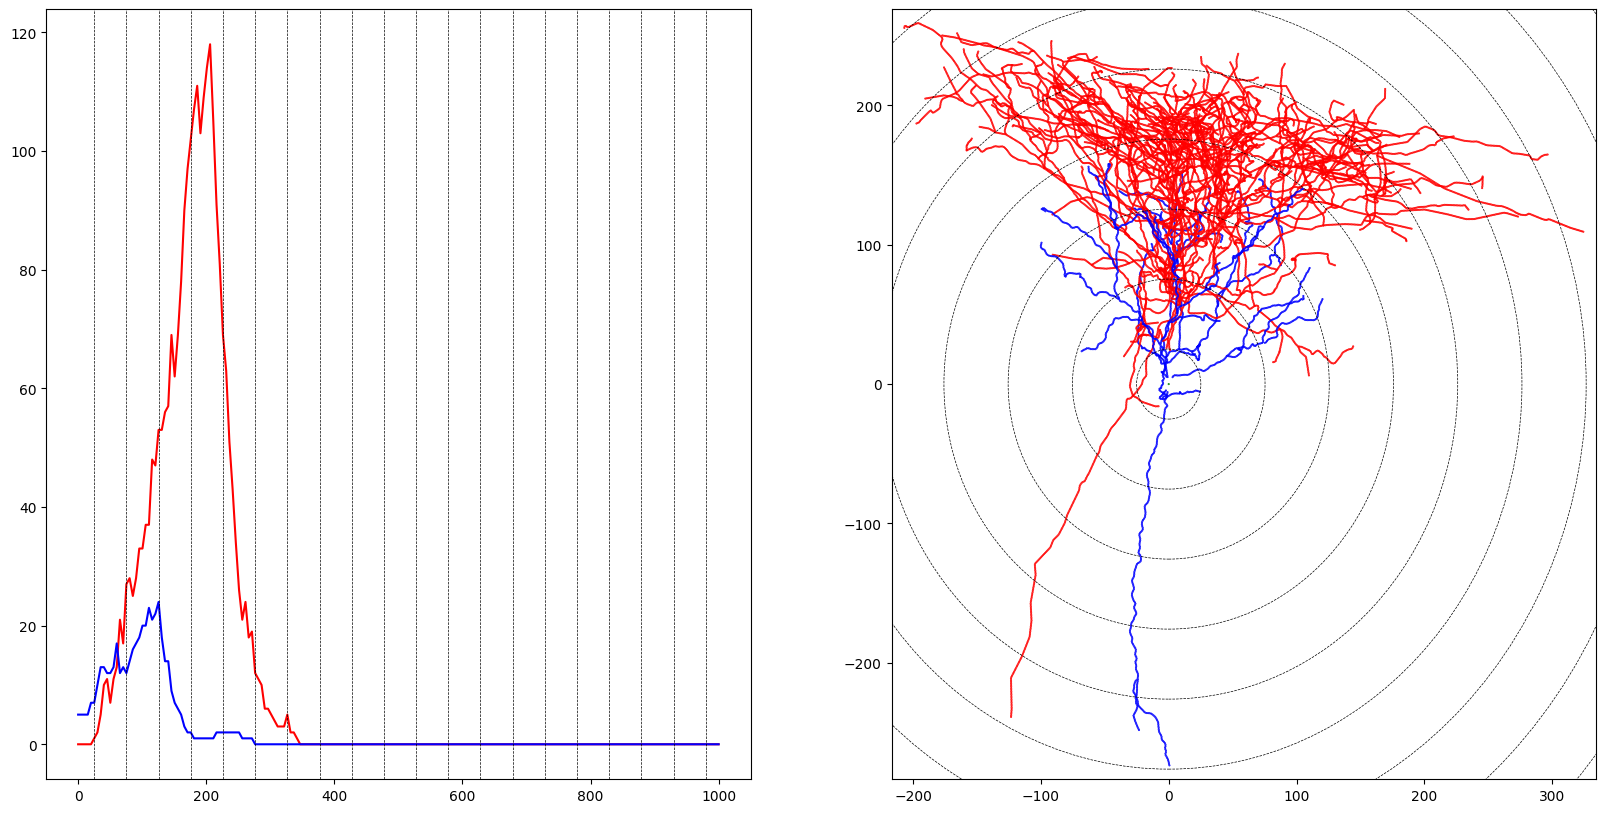

In [120]:
sp_idx = 520

arbor_map = {0: 2, 1: 3, 2: 4, 3: 3}
color_dict = {1: 'g', 2: 'r', 3: 'b', 4: 'k'}
color_list = [color_dict[int(t)] for t in swc_data["swc_types"][sp_idx]]
(fig, (sholl_ax, swc_ax)) = plt.subplots(1, 2, figsize = (20, 10))
for arbor_idx in range(4):
    vec = sholl_vector[sp_idx, :, arbor_idx]
    if np.any(vec > 0):
        sholl_ax.plot(steps, vec, c = color_dict[arbor_map[arbor_idx]])
coords = swc_data["swc_upright"][sp_idx]
swc_ax.scatter(coords[:, 0], coords[:, 1], marker = ".", s = 1, c = color_list)
for radius in steps[5::10]:
    circle = plt.Circle((0, 0), radius, fc = "None", color = "black", linestyle = "dashed", lw = 0.5)
    swc_ax.add_patch(circle)
    sholl_ax.axvline(radius, color = "black", linestyle = "dashed", lw = 0.5)
swc_ax.set_xlim((coords[:, 0].min() - 10, coords[:, 0].max() + 10))
swc_ax.set_ylim((coords[:, 1].min() - 10, coords[:, 1].max() + 10))
plt.show()

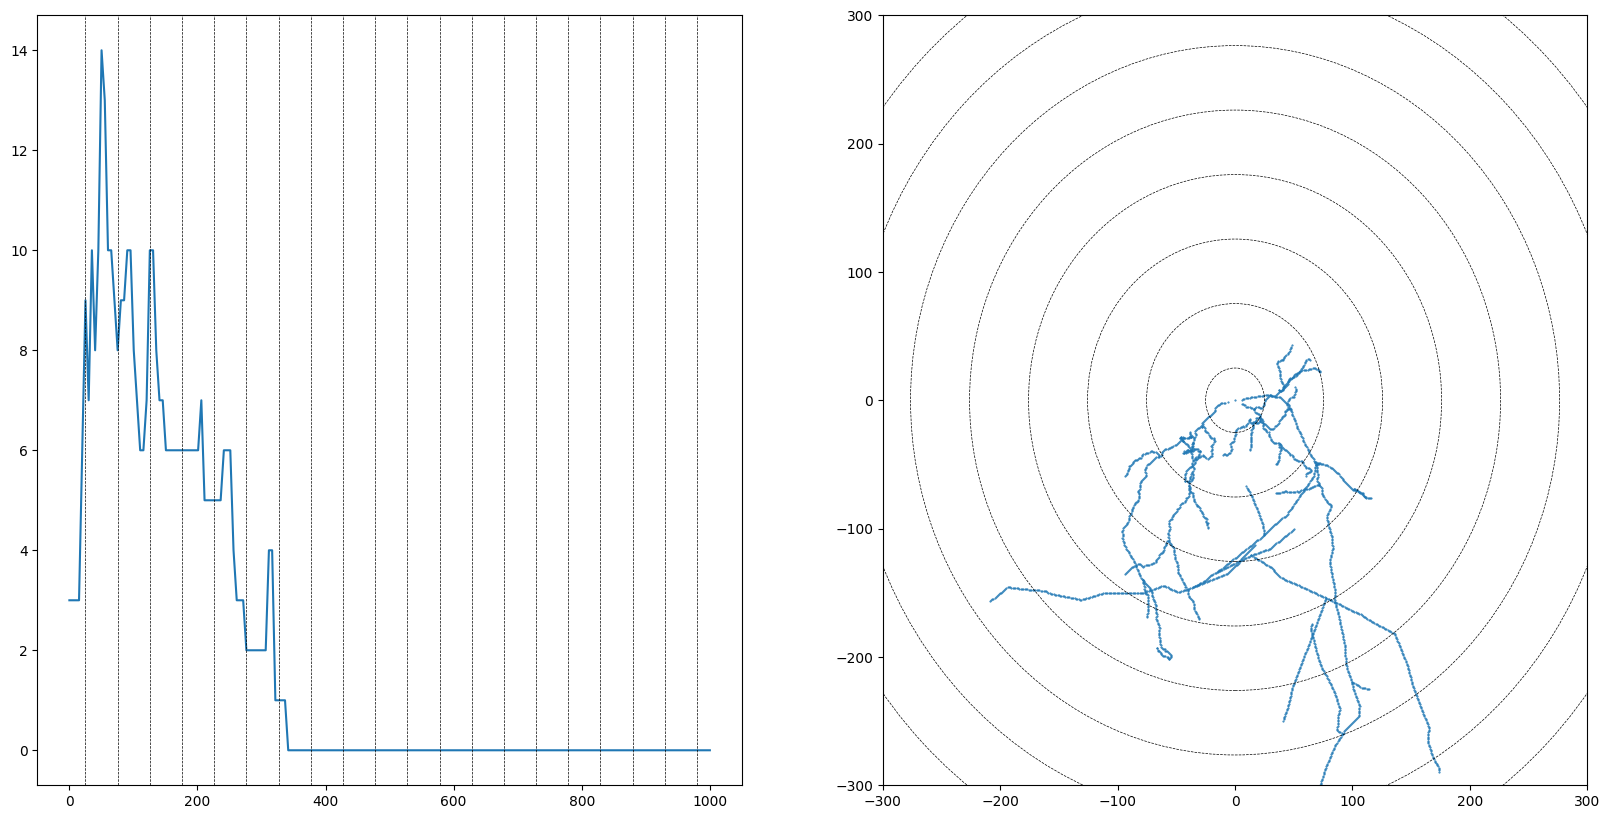

In [ ]:
(fig, (sholl_ax, swc_ax)) = plt.subplots(1, 2, figsize = (20, 10))
sholl_ax.plot(steps, sholl_vector)
swc_ax.scatter(swc_coords[:, 0], swc_coords[:, 1], marker = ".", s = 1)
for radius in steps[5::10]:
    circle = plt.Circle((0, 0), radius, fc = "None", color = "black", linestyle = "dashed", lw = 0.5)
    swc_ax.add_patch(circle)
    sholl_ax.axvline(radius, color = "black", linestyle = "dashed", lw = 0.5)
swc_ax.set_xlim((-300, 300))
swc_ax.set_ylim((-300, 300))
plt.show()